<a href="https://colab.research.google.com/github/sathursiyakrishnamoorthy/Data-Science-Project-Hotel-A/blob/EDA-Phase/DataScienceEDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1. summary statistics for numerical variables

In [ ]:
import pandas as pd
# Load the training csv data
df = pd.read_csv('/content/drive/MyDrive/Data Science/Hotel-A-train.csv')

In [ ]:
# Summary statistics for numerical features
# min, max, std, median, and quartiles
numerical_summary = df.describe(percentiles=[.25, .5, .75]).T
numerical_summary = numerical_summary[['min', 'max', 'std', '50%', '25%', '75%']]
numerical_summary.rename(columns={'50%': 'median'}, inplace=True)

print("Numerical Summary Statistics:")
display(numerical_summary)

Numerical Summary Statistics:


,min,max,std,median,25%,75%
Reservation-id,3154.0,99999005.0,2.886911e+07,50149955.0,25239432.0,75182883.0
Age,18.0,70.0,1.530315e+01,44.0,31.0,57.0
Adults,1.0,5.0,1.176526e+00,2.0,2.0,3.0
Children,1.0,3.0,7.219721e-01,2.0,1.0,2.0
Babies,0.0,2.0,5.733259e-01,0.0,0.0,1.0
Discount_Rate,0.0,40.0,1.120604e+01,10.0,5.0,20.0
Room_Rate,100.0,250.0,4.387709e+01,175.0,137.0,214.0


2. summary statistics for categorical variables

In [ ]:
# summary statistics for categorical features
categorical_summary = df.describe(include=['object', 'category']).T
print("\nCategorical Summary Statistics:")
display(categorical_summary)


Categorical Summary Statistics:


,count,unique,top,freq
Gender,27499,2,F,13799
Ethnicity,27499,4,African American,6965
Educational_Level,27499,4,College,11052
Income,27499,4,50K -- 100K,7936
Country_region,27499,4,South,10917
Hotel_Type,27499,3,Airport Hotels,9258
Expected_checkin,27499,901,2/9/2016,145
Expected_checkout,27499,929,3/14/2016,91
Booking_date,27499,1133,10/19/2015,232
Meal_Type,27499,3,BB,14224


3. Identifying data quality issues

In [ ]:
# missing values analysis
missing_values = df.isnull().sum()
missing_values

,0
Reservation-id,0
Gender,0
Age,0
Ethnicity,0
Educational_Level,0
Income,0
Country_region,0
Hotel_Type,0
Expected_checkin,0
Expected_checkout,0


In [ ]:
missing_values_percentage = (missing_values / len(df)) * 100
missing_values_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_values_percentage
})
missing_values_df = missing_values_df[missing_values_df["Missing Values"] > 0].sort_values(by="Missing Values", ascending=False)
display(missing_values_df)

,Missing Values,Percentage


In [ ]:
#outlier analysis for room mates
# Check for Room_Rate outliers (0 or negative values)
invalid_rates = df[df['Room_Rate'] <= 0]

print(f"Number of records with 0 or negative Room_Rate: {len(invalid_rates)}")
if len(invalid_rates) > 0:
    display(invalid_rates[['Reservation-id', 'Room_Rate']].head())

Number of records with 0 or negative Room_Rate: 0


In [ ]:
#logical inconsistencies with guests
# Check if Adults + Children exceed the limit of 5
df['Total_Guests'] = df['Adults'] + df['Children']
inconsistent_guests = df[df['Total_Guests'] > 5]

print(f"Number of records exceeding guest limit (5): {len(inconsistent_guests)}")
if len(inconsistent_guests) > 0:
    display(inconsistent_guests[['Reservation-id', 'Adults', 'Children', 'Total_Guests']].head())

Number of records exceeding guest limit (5): 4369


,Reservation-id,Adults,Children,Total_Guests
1,77491756,3,3,6
2,73747291,3,3,6
3,67301739,4,3,7
5,55152245,5,2,7
11,41573356,4,3,7


4. cancellation trend analysisi

Feature engineering (phase 1)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Data Science/Hotel-A-train.csv')

# 1. Feature Engineering: Create Lead_Time and Stay_Duration
df['Booking_date'] = pd.to_datetime(df['Booking_date'])
df['Expected_checkin'] = pd.to_datetime(df['Expected_checkin'])
df['Expected_checkout'] = pd.to_datetime(df['Expected_checkout'])

df['Lead_Time'] = (df['Expected_checkin'] - df['Booking_date']).dt.days
df['Stay_Duration'] = (df['Expected_checkout'] - df['Expected_checkin']).dt.days

# 2. Calculate Revenue Loss per booking
# (Room_Rate adjusted for Discount)
df['Net_Revenue'] = df['Room_Rate'] * (1 - df['Discount_Rate']/100)


print("Preprocessing is done. New features are: Lead_Time, Stay_Duration, Net_Revenue.")

Preprocessing is done. New features are: Lead_Time, Stay_Duration, Net_Revenue.


Univariate analysis

/tmp/ipykernel_153/2579103257.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Deposit_type', ax=axes[0,0], palette='magma')


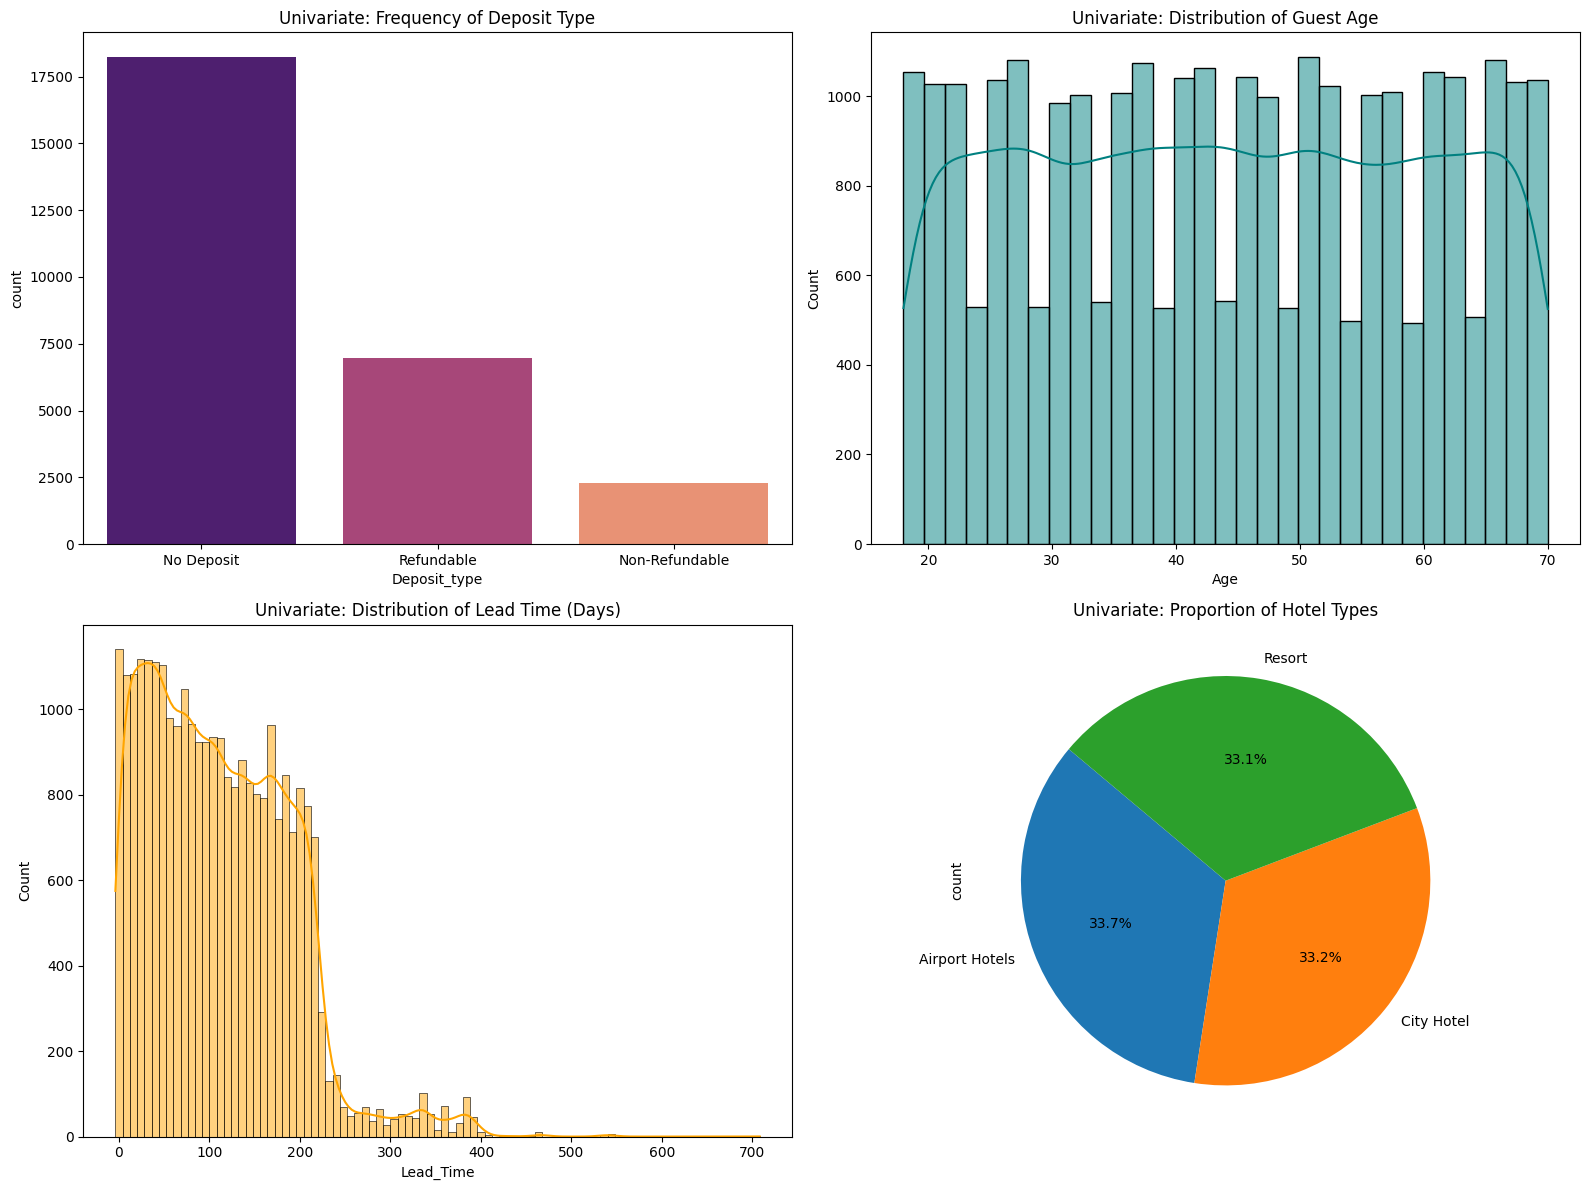

In [ ]:
# Create a dashboard for Univariate Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Target Variable Balance
sns.countplot(data=df, x='Deposit_type', ax=axes[0,0], palette='magma')
axes[0,0].set_title('Univariate: Frequency of Deposit Type')

# Chart 2: Age Distribution
sns.histplot(df['Age'], kde=True, ax=axes[0,1], color='teal')
axes[0,1].set_title('Univariate: Distribution of Guest Age')

# Chart 3: Lead Time Distribution
sns.histplot(df['Lead_Time'], kde=True, ax=axes[1,0], color='orange')
axes[1,0].set_title('Univariate: Distribution of Lead Time (Days)')

# Chart 4: Hotel Type Proportion
df['Hotel_Type'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1,1], startangle=140)
axes[1,1].set_title('Univariate: Proportion of Hotel Types')

plt.tight_layout()
plt.show()

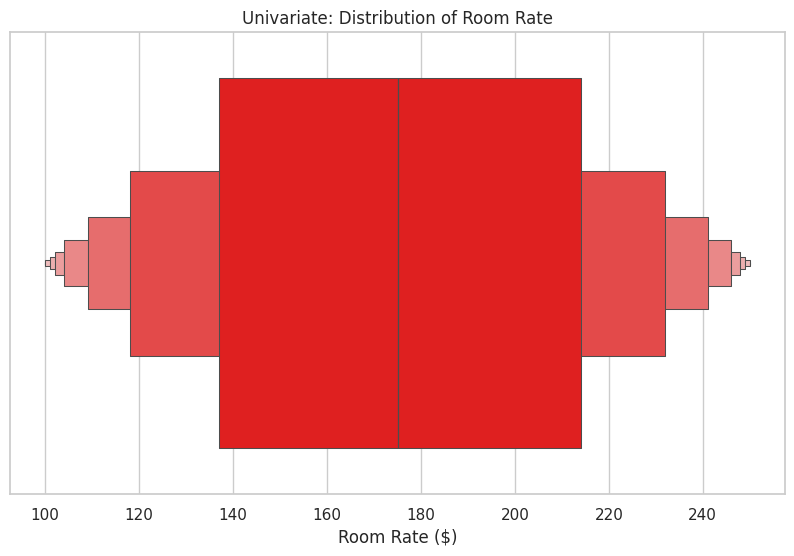

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the theme for a professional look
sns.set_theme(style="whitegrid")

# Create a single plot (no subplots)
plt.figure(figsize=(10, 6))

# Plotting the Room Rate
sns.boxenplot(x=df['Room_Rate'], color='red')

# Adding titles and labels
plt.title('Univariate: Distribution of Room Rate')
plt.xlabel('Room Rate ($)')

# Display the plot
plt.show()

/tmp/ipykernel_153/3507472770.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Reservation_Status', data=df, palette='Set2')


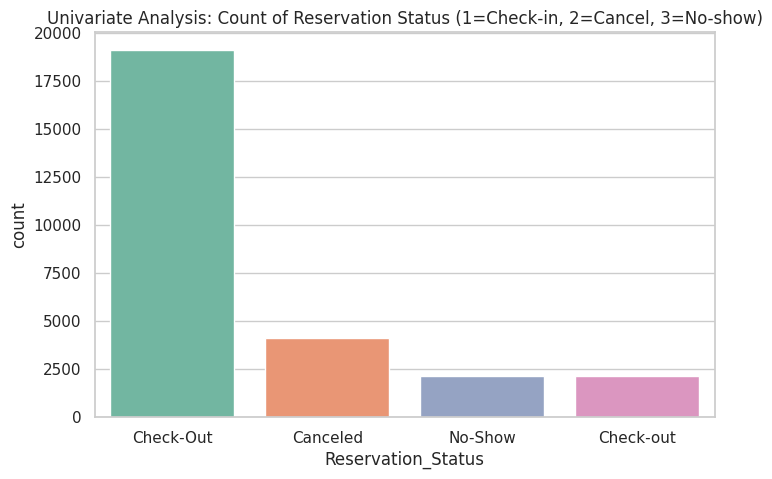

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Univariate: Distribution of the target variable (Reservation_Status)
plt.figure(figsize=(8, 5))
sns.countplot(x='Reservation_Status', data=df, palette='Set2')
plt.title('Univariate Analysis: Count of Reservation Status (1=Check-in, 2=Cancel, 3=No-show)')
plt.show()

/tmp/ipykernel_153/3114278487.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Income', order=income_order, palette='viridis')


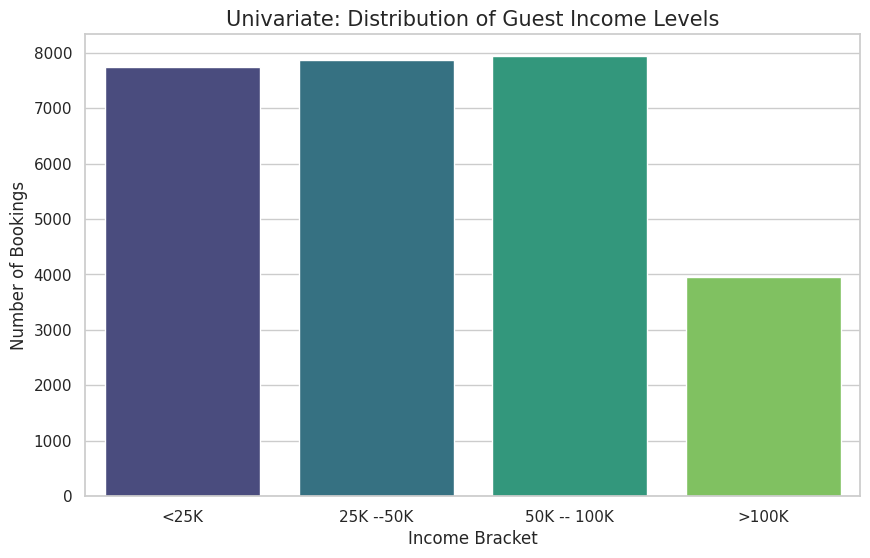

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the theme
sns.set_theme(style="whitegrid")

# Create a single plot
plt.figure(figsize=(10, 6))

# Define the logical order of income categories
income_order = ['<25K', '25K --50K', '50K -- 100K', '>100K']

# Plotting the Income distribution
sns.countplot(data=df, x='Income', order=income_order, palette='viridis')

# Adding titles and labels
plt.title('Univariate: Distribution of Guest Income Levels', fontsize=15)
plt.xlabel('Income Bracket', fontsize=12)
plt.ylabel('Number of Bookings', fontsize=12)

# Display the plot
plt.show()

Bivariate analysis

In [ ]:
import pandas as pd

<Figure size 1000x600 with 0 Axes>

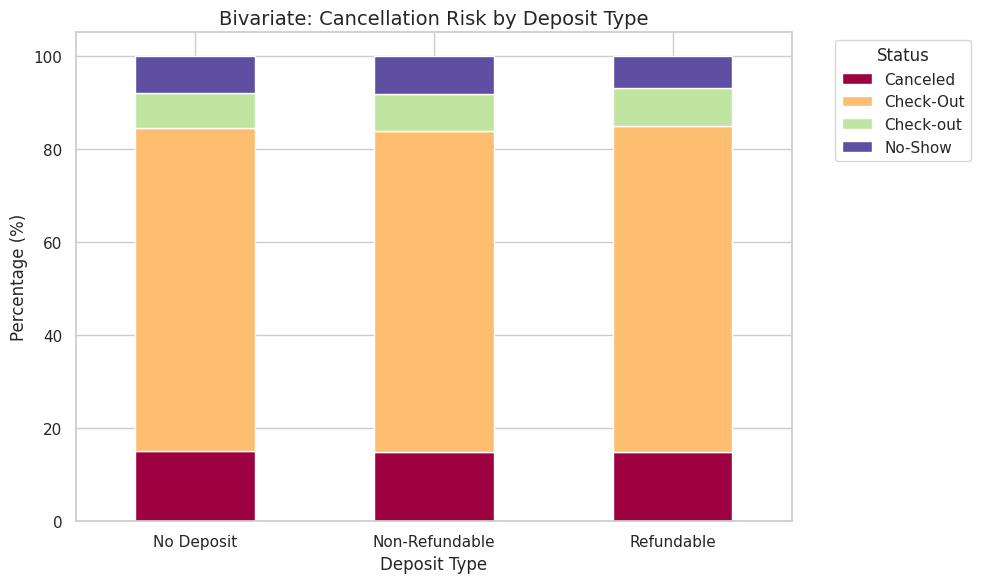

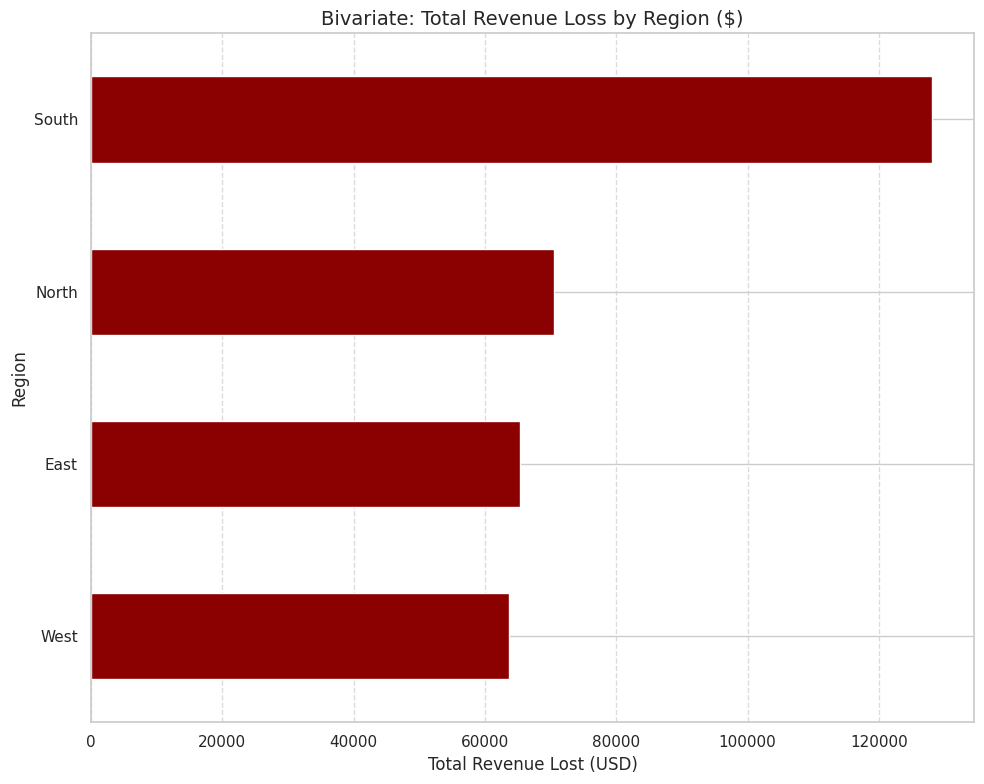

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the plotting theme is set
sns.set_theme(style="whitegrid")

# --- CHART 1: Deposit Type vs Status (Risk Assessment) ---
plt.figure(figsize=(10, 6))

# Create crosstab and normalize to get percentages
ct = pd.crosstab(df['Deposit_type'], df['Reservation_Status'], normalize='index') * 100

# Fix: Explicitly convert to float to prevent "no numeric data to plot" errors
ct_float = ct.astype(float)

# Plotting
ax = ct_float.plot(kind='bar', stacked=True, colormap='Spectral', figsize=(10, 6))

plt.title('Bivariate: Cancellation Risk by Deposit Type', fontsize=14)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Deposit Type', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# --- CHART 2: Revenue Loss by Region (Quantifying Loss) ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure Net_Revenue is numeric
df['Net_Revenue'] = pd.to_numeric(df['Net_Revenue'], errors='coerce')

# Filter for only Canceled (2) and No-Shows (3)
# Using a more robust filter in case status is stored as string or int
loss_only = df[df['Reservation_Status'].astype(str).isin(['canceled', 'No-Show'])].copy()


plt.figure(figsize=(10, 8))
#Group, sum, and force result to float
loss_by_region = loss_only.groupby('Country_region')['Net_Revenue'].sum().sort_values()
loss_by_region = loss_by_region.astype(float) # The Fix

# Plotting
loss_by_region.plot(kind='barh', color='darkred')

plt.title('Bivariate: Total Revenue Loss by Region ($)', fontsize=14)
plt.xlabel('Total Revenue Lost (USD)', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Multivariate

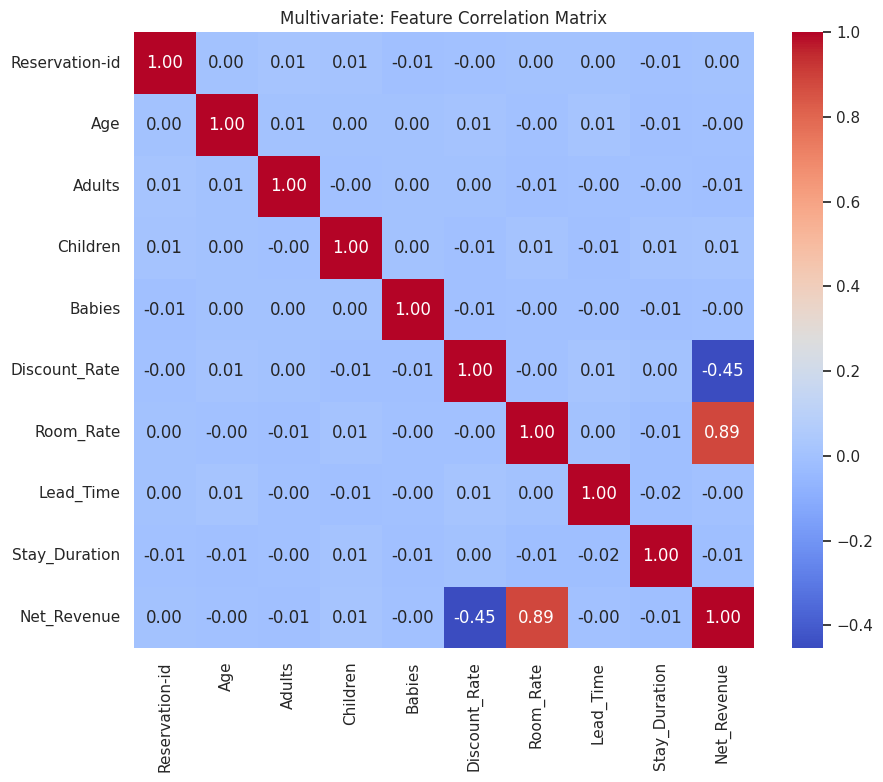

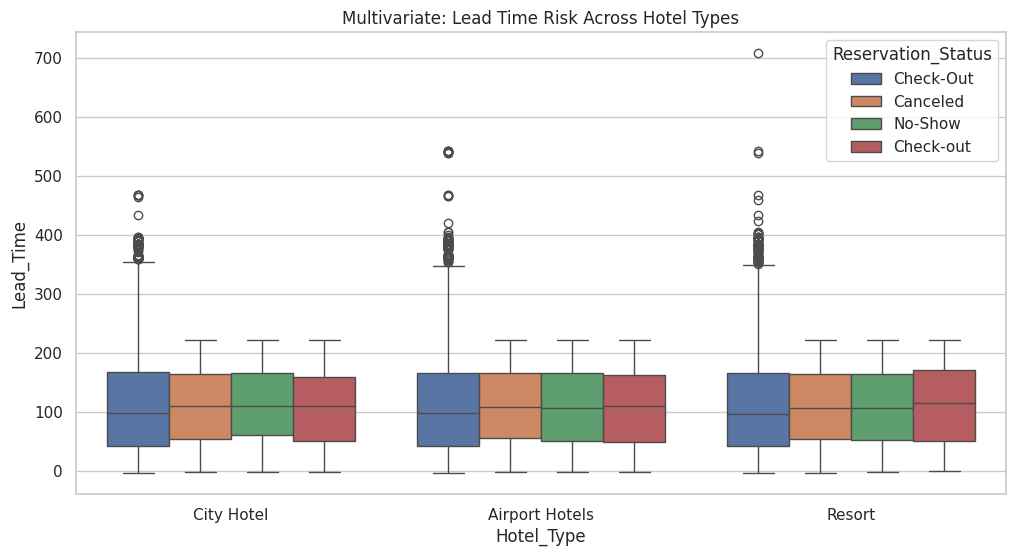

In [ ]:
# 1. Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Multivariate: Feature Correlation Matrix')
plt.show()

# 2. Interaction: Hotel Type, Lead Time, and Status
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Hotel_Type', y='Lead_Time', hue='Reservation_Status')
plt.title('Multivariate: Lead Time Risk Across Hotel Types')
plt.show()